In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter joblib flask

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
# IMPORT REQUIRED LIBRARIES

# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Class balancing
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save model
import joblib

Load Dataset

In [70]:
# Load CSV dataset
data = pd.read_csv("../../dataset/learnict_student_performance.csv")

In [71]:
# Display first 5 rows
data.head()

,attendance_percentage,avg_unit_marks,sir_term_test_avg,school_term_test_avg,homework_completion_rate,behavior_score,final_grade
0,82.45,62.23,72.95,91.51,65.32,71.49,B
1,98.69,80.35,50.61,69.94,60.73,68.01,B
2,78.63,26.73,25.50,45.63,49.74,79.71,W
3,61.38,36.75,89.31,53.03,71.35,53.63,S
4,66.83,67.22,36.98,66.27,57.99,70.62,C


Note:

This dataset represents aggregated student performance indicators derived from multiple module-level academic records.
Although the operational web system stores detailed module-wise records, the machine learning model uses summarized indicators such as attendance percentage, average unit marks, average term test marks, homework completion rate, and behavior score for final grade prediction.


Dataset Overview

In [72]:
# Dataset shape (rows, columns)
print("Dataset Shape:", data.shape)

Dataset Shape: (5000, 7)


In [73]:
# Column information
print("\nDataset Info:")
data.info()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   attendance_percentage     5000 non-null   float64
 1   avg_unit_marks            5000 non-null   float64
 2   sir_term_test_avg         5000 non-null   float64
 3   school_term_test_avg      5000 non-null   float64
 4   homework_completion_rate  5000 non-null   float64
 5   behavior_score            5000 non-null   float64
 6   final_grade               5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [75]:
# Statistical summary
print("\nStatistical Summary:")
display(data.describe())


Statistical Summary:


,attendance_percentage,avg_unit_marks,sir_term_test_avg,school_term_test_avg,homework_completion_rate,behavior_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,74.739290,64.768456,60.025132,57.840794,69.506494,74.781142
std,14.599729,18.903025,19.110800,20.499721,19.012284,14.174113
min,30.000000,20.000000,20.000000,20.000000,10.000000,30.000000
25%,64.580000,51.235000,46.637500,42.897500,56.392500,65.180000
50%,74.945000,65.040000,60.245000,57.860000,70.135000,75.010000
75%,85.565000,78.460000,73.450000,72.112500,83.832500,84.912500
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [76]:
# Check missing values
missing_values = data.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
attendance_percentage       0
avg_unit_marks              0
sir_term_test_avg           0
school_term_test_avg        0
homework_completion_rate    0
behavior_score              0
final_grade                 0
dtype: int64


In [77]:
# Check Duplicates

duplicate_count = data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


Class Distribution

In [80]:
# Check grade distribution
grade_counts = data['final_grade'].value_counts()

print("Final Grade Distribution:")
print(grade_counts)

Final Grade Distribution:
final_grade
C    2163
S    1290
B    1169
W     214
A     164
Name: count, dtype: int64


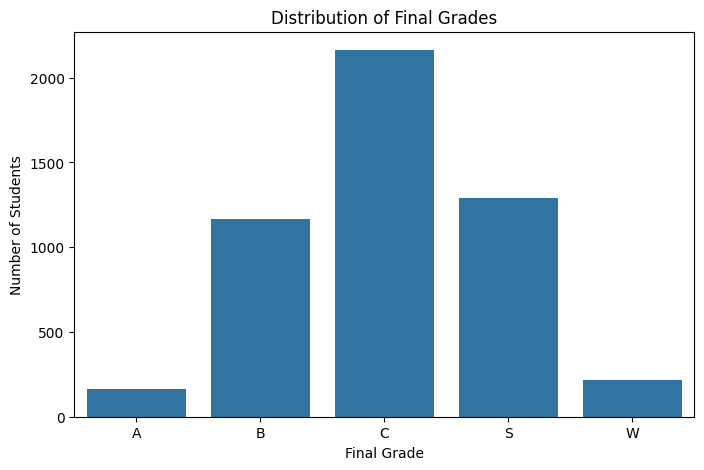

In [81]:
#Visualization

plt.figure(figsize=(8, 5))
sns.countplot(x='final_grade', data=data, order=sorted(data['final_grade'].unique()))
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

Feature engineering - Performance Trend

In [82]:
# This feature compares unit exam performance with school term performance.
# It helps identify whether the student is improving, declining, or stable.

def get_trend(row):
    if row['school_term_test_avg'] > row['avg_unit_marks']:
        return "improving"
    elif row['school_term_test_avg'] < row['avg_unit_marks']:
        return "declining"
    else:
        return "stable"

data['performance_trend'] = data.apply(get_trend, axis=1)

# Show updated data
data.head()

,attendance_percentage,avg_unit_marks,sir_term_test_avg,school_term_test_avg,homework_completion_rate,behavior_score,final_grade,performance_trend
0,82.45,62.23,72.95,91.51,65.32,71.49,B,improving
1,98.69,80.35,50.61,69.94,60.73,68.01,B,declining
2,78.63,26.73,25.50,45.63,49.74,79.71,W,improving
3,61.38,36.75,89.31,53.03,71.35,53.63,S,improving
4,66.83,67.22,36.98,66.27,57.99,70.62,C,declining


In [83]:
#Check trend distribution

print(data['performance_trend'].value_counts())

performance_trend
declining    3009
improving    1987
stable          4
Name: count, dtype: int64


Outlier Detection using IQR

In [84]:
numeric_columns = [
    'attendance_percentage',
    'avg_unit_marks',
    'sir_term_test_avg',
    'school_term_test_avg',
    'homework_completion_rate',
    'behavior_score'
]

outlier_summary = {}

for col in numeric_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

print("Outlier Summary:")
print(outlier_summary)

Outlier Summary:
{'attendance_percentage': 13, 'avg_unit_marks': 0, 'sir_term_test_avg': 0, 'school_term_test_avg': 0, 'homework_completion_rate': 22, 'behavior_score': 17}


In [85]:
# Remove outliers column by column using IQR method

for col in numeric_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

print("Shape after outlier removal:", data.shape)

Shape after outlier removal: (4951, 8)


DATA VISUALIZATION

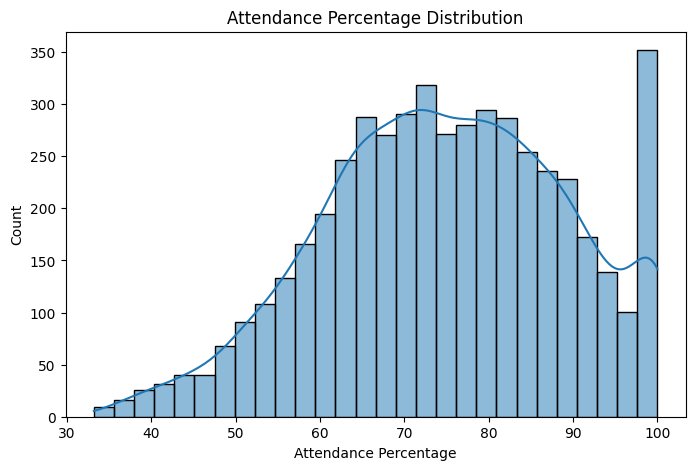

In [87]:
# Distribution of attendance percentage

plt.figure(figsize=(8, 5))
sns.histplot(data['attendance_percentage'], kde=True)
plt.title("Attendance Percentage Distribution")
plt.xlabel("Attendance Percentage")
plt.show()

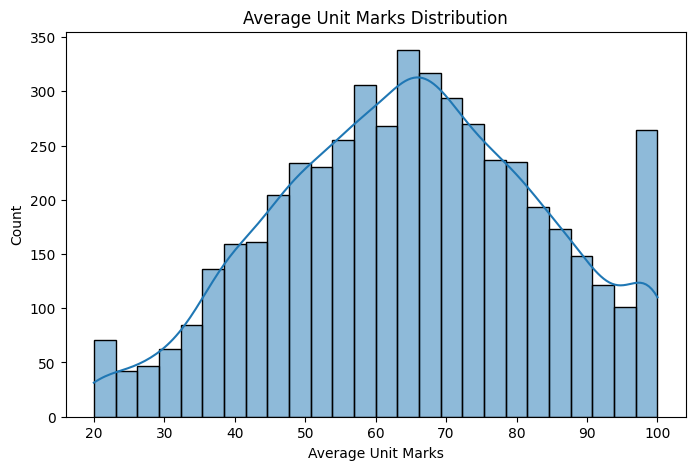

In [90]:
# Distribution of average unit marks

plt.figure(figsize=(8, 5))
sns.histplot(data['avg_unit_marks'], kde=True)
plt.title("Average Unit Marks Distribution")
plt.xlabel("Average Unit Marks")
plt.show()

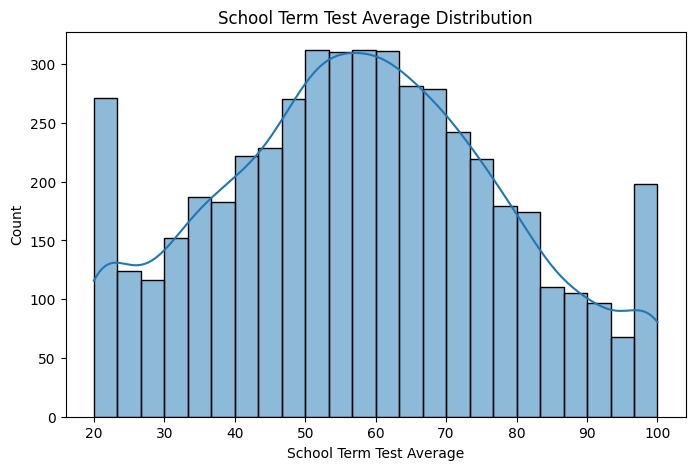

In [91]:
# Distribution of school term test average

plt.figure(figsize=(8, 5))
sns.histplot(data['school_term_test_avg'], kde=True)
plt.title("School Term Test Average Distribution")
plt.xlabel("School Term Test Average")
plt.show()

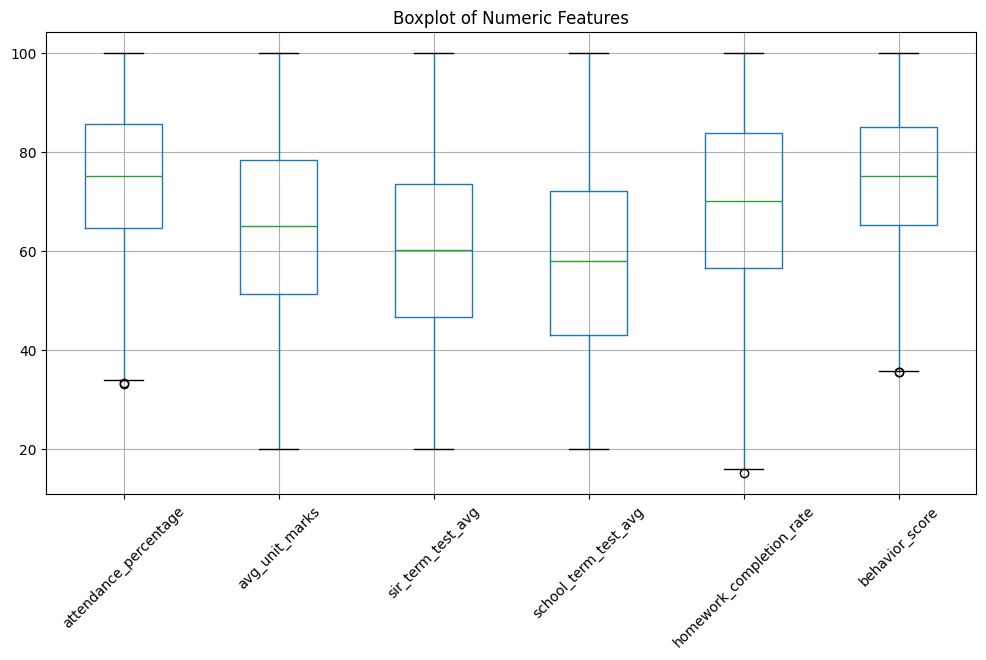

In [92]:
# Boxplot for numeric features

plt.figure(figsize=(12, 6))
data[numeric_columns].boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.show()

Correlation Analysis

In [93]:
# Compute correlation matrix
correlation_matrix = data[numeric_columns].corr()

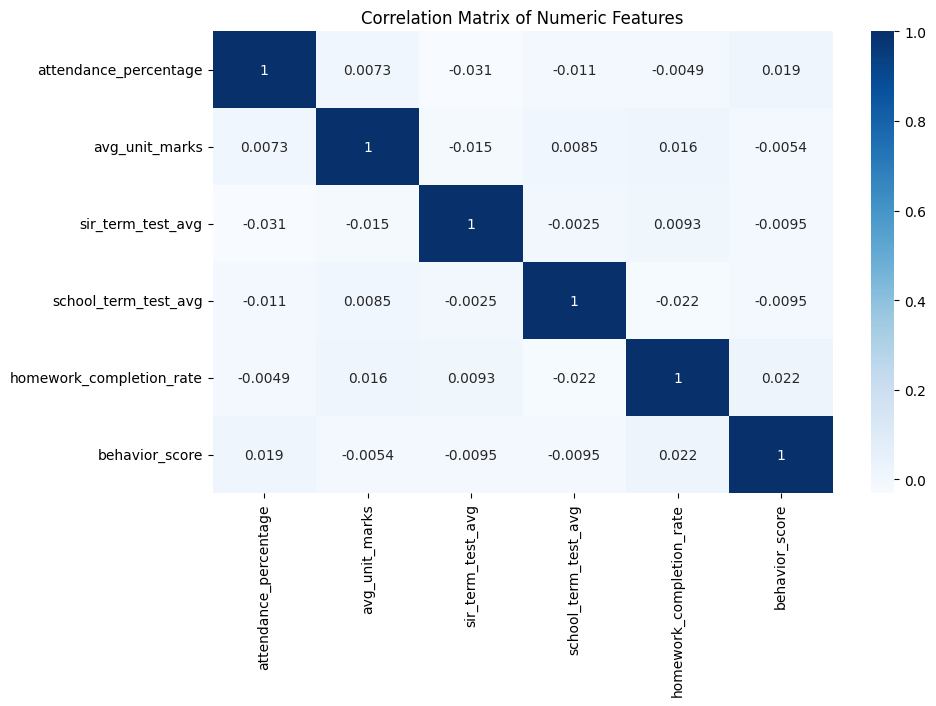

In [94]:
#Visualization

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues')
plt.title("Correlation Matrix of Numeric Features")
plt.show()

Data Preprocessing

In [95]:
# ENCODE TARGET AND TREND FEATURES

# Encode final grade labels
grade_encoder = LabelEncoder()
data['grade_encoded'] = grade_encoder.fit_transform(data['final_grade'])

# Encode performance trend labels
trend_encoder = LabelEncoder()
data['trend_encoded'] = trend_encoder.fit_transform(data['performance_trend'])

# Display encoded values
data[['final_grade', 'grade_encoded', 'performance_trend', 'trend_encoded']].head()

,final_grade,grade_encoded,performance_trend,trend_encoded
0,B,1,improving,1
1,B,1,declining,0
2,W,4,improving,1
3,S,3,improving,1
4,C,2,declining,0


In [96]:
print("Grade Classes:", grade_encoder.classes_)
print("Trend Classes:", trend_encoder.classes_)

Grade Classes: ['A' 'B' 'C' 'S' 'W']
Trend Classes: ['declining' 'improving' 'stable']


Feature selection

In [97]:
# SELECT FEATURES AND TARGET

X = data[
    [
        'attendance_percentage',
        'avg_unit_marks',
        'sir_term_test_avg',
        'school_term_test_avg',
        'homework_completion_rate',
        'behavior_score',
        'trend_encoded'
    ]
]

y = data['grade_encoded']

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (4951, 7)
Target Vector Shape: (4951,)


Train-test split

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3960, 7)
X_test shape: (991, 7)
y_train shape: (3960,)
y_test shape: (991,)


Feature scaling

In [100]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Class Balancing using SMOTE

In [101]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_balanced).value_counts())

Before SMOTE: grade_encoded
2    1716
3    1021
1     930
4     162
0     131
Name: count, dtype: int64
After SMOTE: grade_encoded
3    1716
2    1716
0    1716
4    1716
1    1716
Name: count, dtype: int64


Train Models

1. Logistic Regression

In [113]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_balanced, y_train_balanced)

lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9505549949545913


2. Random Forest

In [114]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

rf_pred = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8486377396569122


3. Gradient Boosting

In [115]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_balanced, y_train_balanced)

gb_pred = gb_model.predict(X_test_scaled)
gb_acc = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 0.8335015136226034


4. SVM

In [116]:
svm_model = SVC()
svm_model.fit(X_train_balanced, y_train_balanced)

svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.929364278506559


Model Comparison

In [117]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'SVM'
    ],
    'Accuracy': [
        lr_acc,
        rf_acc,
        gb_acc,
        svm_acc
    ]
})

results = results.sort_values(by='Accuracy', ascending=False)
display(results)

,Model,Accuracy
0,Logistic Regression,0.950555
3,SVM,0.929364
1,Random Forest,0.848638
2,Gradient Boosting,0.833502


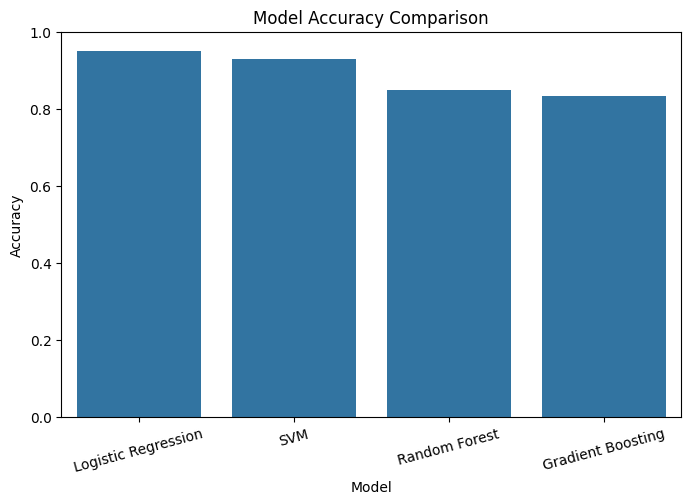

In [118]:
#Graph

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

In [131]:
#Select best model

best_model = lr_model
best_predictions = lr_pred

print("Selected Best Model: Logistic Regression")

Selected Best Model: Logistic Regression


Classification Report

In [132]:
print("Classification Report for Best Model:\n")
print(classification_report(y_test, best_predictions))

Classification Report for Best Model:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89        33
           1       0.95      0.97      0.96       233
           2       1.00      0.94      0.97       430
           3       0.95      0.94      0.94       255
           4       0.71      1.00      0.83        40

    accuracy                           0.95       991
   macro avg       0.88      0.97      0.92       991
weighted avg       0.96      0.95      0.95       991



Confusion Matrix (Best Model)

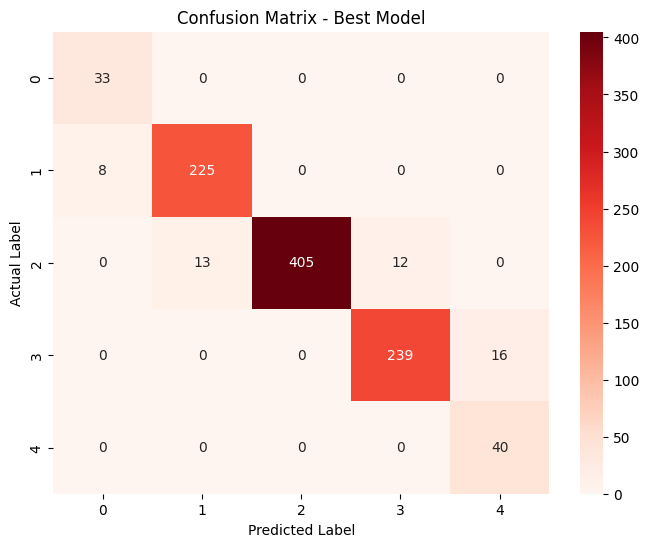

In [133]:
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Student risk Score Function

In [134]:
#Student Risk Score Calculation

def calculate_risk_score(attendance, unit_marks, sir_term, school_term, homework, behavior):
    """
    This function calculates a student risk score out of 100.
    Higher risk score means higher risk of underperformance.
    """

    weighted_score = (
        attendance * 0.20 +
        unit_marks * 0.20 +
        sir_term * 0.20 +
        school_term * 0.25 +
        homework * 0.10 +
        behavior * 0.05
    )

    risk_score = 100 - weighted_score
    return round(risk_score, 2)

In [135]:
#Risk level function

def get_risk_level(score):
    """
    Converts the numeric risk score into a category.
    """

    if score <= 30:
        return "LOW"
    elif score <= 60:
        return "MEDIUM"
    else:
        return "HIGH"

In [136]:
#Test

sample_risk = calculate_risk_score(78, 70, 68, 72, 80, 85)
sample_level = get_risk_level(sample_risk)

print("Sample Risk Score:", sample_risk)
print("Sample Risk Level:", sample_level)

Sample Risk Score: 26.55
Sample Risk Level: LOW


In [137]:
#Save model and Preprocessing objects

joblib.dump(best_model, "../saved_model/model.pkl")
joblib.dump(scaler, "../saved_model/scaler.pkl")
joblib.dump(grade_encoder, "../saved_model/grade_encoder.pkl")
joblib.dump(trend_encoder, "../saved_model/trend_encoder.pkl")

print("Model, scaler, and encoders saved successfully.")

Model, scaler, and encoders saved successfully.
